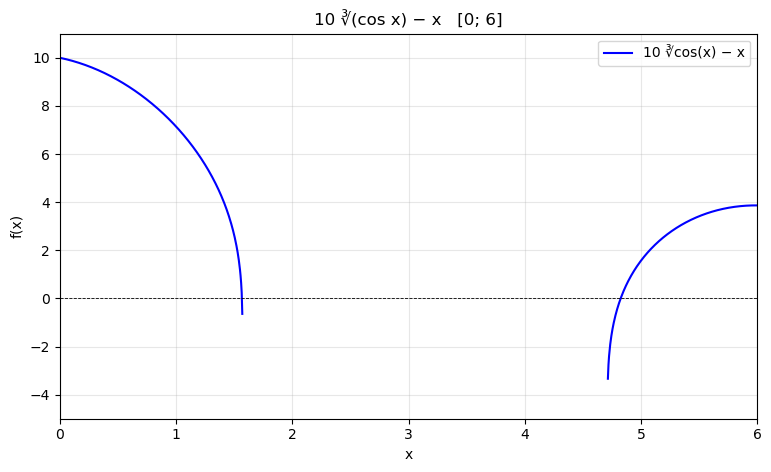

In [1]:
import matplotlib.pyplot as plt
import math

def f(x):
    cx = math.cos(x)
    return 10 * cx**(1/3) - x if cx >= 0 else None

def bisection(a, b, tol=1e-9):
    if f(a) is None or f(b) is None or f(a) * f(b) > 0:
        return None
    while b - a > tol:
        c = (a + b) / 2
        if f(c) is None:
            return None
        if f(c) == 0 or abs(f(c)) < tol:
            return c
        if f(a) * f(c) < 0:
            b = c
        else:
            a = c
    return (a + b) / 2

# График
x = [i/200 for i in range(1201)]
y = [f(xi) for xi in x]

plt.figure(figsize=(9, 5))
plt.plot(x, y, 'b-', label='10 ∛cos(x) − x')
plt.axhline(0, color='k', lw=0.6, ls='--')

# Поиск корней
for interval in [(1.0, 1.6), (5.0, 5.8)]:
    root = bisection(*interval)
    if root:
        plt.plot(root, f(root), 'ro', ms=9, label=f'корень ≈ {root:.5f}' if 'label' not in plt.gca().get_legend().get_texts() else "")
        print(f"Корень: {root:.6f}")

plt.grid(alpha=0.3)
plt.title("10 ∛(cos x) − x   [0; 6]")
plt.xlabel("x")
plt.ylabel("f(x)")
plt.legend()
plt.xlim(0, 6)
plt.ylim(-5, 11)
plt.show()